<a href="https://colab.research.google.com/github/Girawale-Sanket/Time-Series-Assignment/blob/main/TSA_LAB1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import durbin_watson

In [ ]:
data=pd.read_csv('/content/Bhubaneshwer_data.csv')

In [ ]:
data.head()

,Calendar Day,Sales Qty 5Y
0,11-10-2017,0.5
1,12-10-2017,0.5
2,23-11-2017,0.5
3,24-11-2017,0.5
4,06-12-2017,1.0


In [ ]:
data.shape

(706, 2)

In [ ]:
data.isnull().sum()

,0
Calendar Day,0
Sales Qty 5Y,0


In [ ]:
data.describe()

,Sales Qty 5Y
count,706.000000
mean,9.314589
std,9.371686
min,0.050000
25%,2.668750
50%,6.500000
75%,12.500000
max,59.600000


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 706 entries, 0 to 705
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Calendar Day  706 non-null    object 
 1   Sales Qty 5Y  706 non-null    float64
dtypes: float64(1), object(1)
memory usage: 11.2+ KB


In [ ]:
from datetime import datetime

In [ ]:
data['Calendar Day'] = pd.to_datetime(data['Calendar Day'], format='%d-%m-%Y')

In [ ]:
data['Calendar Day'].dtype

dtype('<M8[ns]')

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 706 entries, 0 to 705
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Calendar Day  706 non-null    datetime64[ns]
 1   Sales Qty 5Y  706 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 11.2 KB


In [ ]:
data.set_index("Calendar Day", inplace=True)

In [ ]:
data.head()

,Sales Qty 5Y
Calendar Day,
2017-10-11,0.5
2017-10-12,0.5
2017-11-23,0.5
2017-11-24,0.5
2017-12-06,1.0


In [ ]:
#sorting
data = data.sort_values("Calendar Day")
data.head()

,Sales Qty 5Y
Calendar Day,
2017-10-11,0.5
2017-10-12,0.5
2017-11-23,0.5
2017-11-24,0.5
2017-12-06,1.0


In [ ]:
Y=data['Sales Qty 5Y'].resample('MS').mean()
Y
#MS= MainSheet or Master Data View

,Sales Qty 5Y
Calendar Day,
2017-10-01,0.500000
2017-11-01,0.500000
2017-12-01,13.388889
2018-01-01,8.187500
2018-02-01,21.000000
2018-03-01,NaN
2018-04-01,3.135714
2018-05-01,6.990000
2018-06-01,6.861538


In [ ]:
Y.fillna(0, inplace=True)

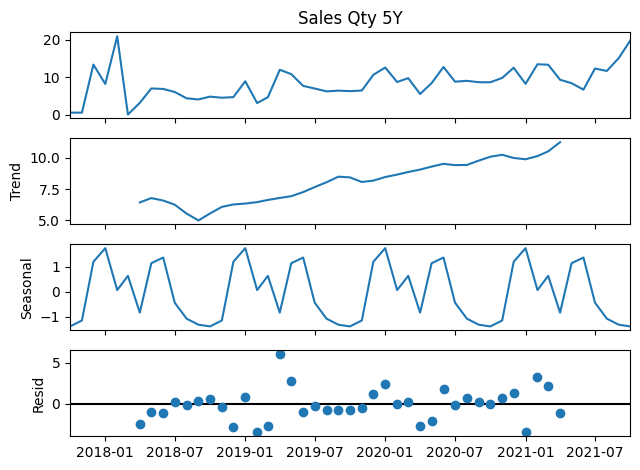

In [ ]:
from pylab import rcParams
decomposition = seasonal_decompose(Y, model='additive')
fig = decomposition.plot()
plt.show()

In [ ]:
for lag in range(1,11):
  print('Lag', lag, ':', Y.corr(Y.shift(lag)))

Lag 1 : 0.26714045703251565
Lag 2 : 0.1497124016652784
Lag 3 : -0.012633537887459512
Lag 4 : 0.01787925385232892
Lag 5 : 0.35495362125031626
Lag 6 : 0.2841612409345628
Lag 7 : 0.2536388479780158
Lag 8 : 0.2810224349867042
Lag 9 : 0.20512102422231152
Lag 10 : 0.16333673292517883


<Figure size 1200x500 with 0 Axes>

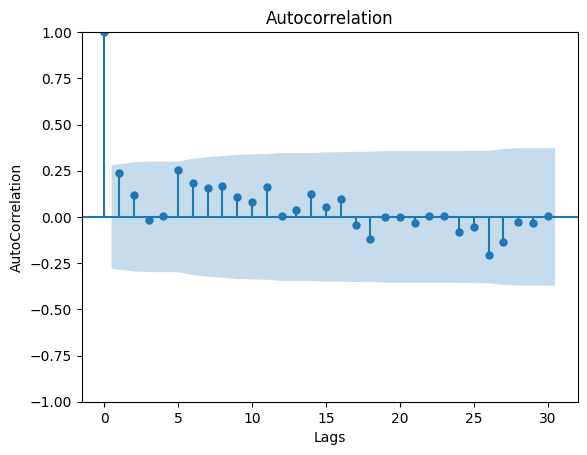

In [ ]:
plt.figure(figsize=(12,5))
plot_acf(Y.dropna(), lags=30) #dropna()= lags(x1,x2,x3...) shift the values to the next and have to discard the previous values
plt.xlabel('Lags')
plt.ylabel('AutoCorrelation')
plt.show()
#blue part in graph is conservetive observations

<Figure size 1200x500 with 0 Axes>

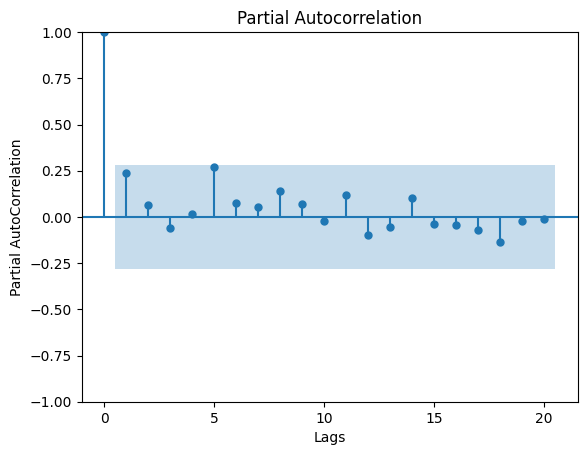

In [ ]:
plt.figure(figsize=(12,5))
plot_pacf(Y.dropna(), lags=20, method='ywm')#ywm= Yule-Walker Method
plt.title('Partial Autocorrelation')
plt.xlabel('Lags')
plt.ylabel('Partial AutoCorrelation')
plt.show()
#If lags> 24 / Value error occurs: Can only compute partial correlations for lags up to 50% of the sample size. The requested nlags 30 must be < 24.

The values we need for ARIMA model

p= pacf gives the p value

q= acf gives the q vaule

d= difference

/tmp/ipykernel_1043/286279443.py:7: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_result = adfuller(Y.dropna())


ADF Statistic: -4.863412125025456
p-value: 4.1067864229844527e-05
Series is STATIONARY (d = 0).


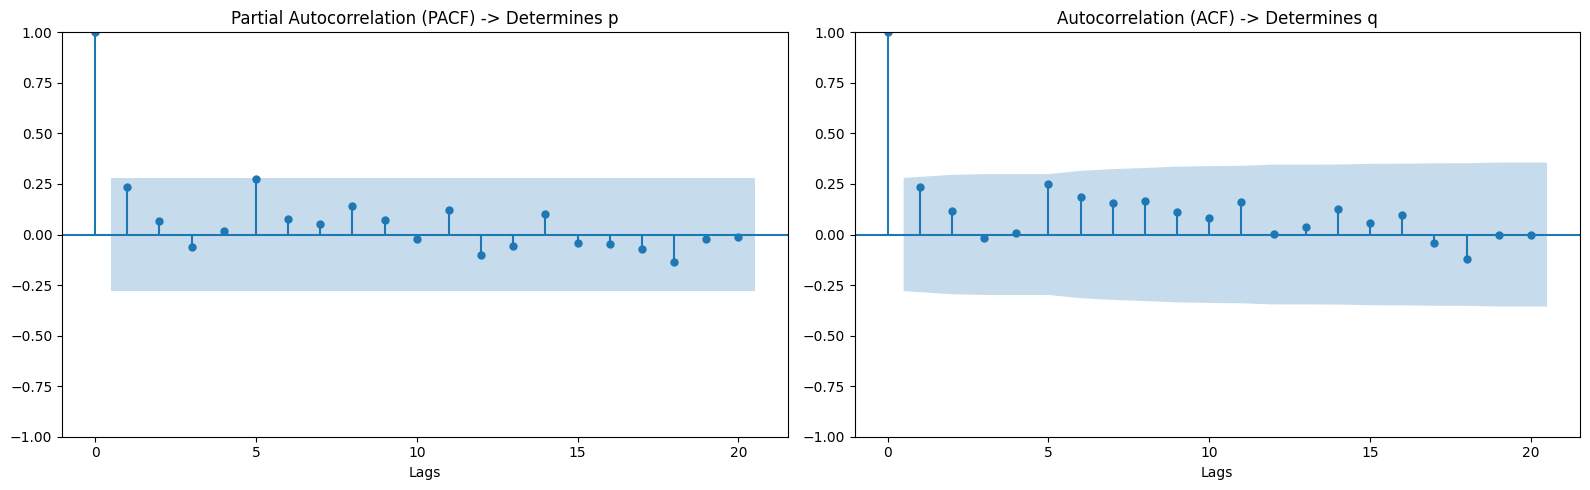

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.19 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=293.981, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=284.941, Time=0.04 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.10 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=292.296, Time=0.02 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=286.310, Time=0.05 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.14 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.19 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=283.663, Time=0.03 sec
 ARIMA(2,1,0)(0,0,0)[0]             : AIC=285.084, Time=0.03 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=277.938, Time=0.04 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=276.363, Time=0.02 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=277.962, Time=0.04 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=279.938, Time=0.08 sec

Best model:  ARIMA(0,1,1)(0,0,0)[0]          
Total fit time: 

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import pmdarima as pm

# 1. FINDING d (Differencing Order) USING ADF TEST
adf_result = adfuller(Y.dropna())
print(f"ADF Statistic: {adf_result[0]}")
print(f"p-value: {adf_result[1]}")

if adf_result[1] > 0.05:
    print("Series is NON-STATIONARY. First differencing required (d = 1 or higher).")
    Y_diff = Y.diff().dropna()
else:
    print("Series is STATIONARY (d = 0).")
    Y_diff = Y.dropna()


# 2. PLOTTING ACF & PACF TO DETERMINE p AND q
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# PACF gives 'p' (AR order) -> look for the last significant lag before it drops into the blue confidence band
plot_pacf(Y_diff, lags=20, method='ywm', ax=axes[0])
axes[0].set_title('Partial Autocorrelation (PACF) -> Determines p')
axes[0].set_xlabel('Lags')

# ACF gives 'q' (MA order) -> look for the last significant lag before it drops into the blue confidence band
plot_acf(Y_diff, lags=20, ax=axes[1])
axes[1].set_title('Autocorrelation (ACF) -> Determines q')
axes[1].set_xlabel('Lags')

plt.tight_layout()
plt.show()


# 3. AUTOMATED OPTIMAL (p, d, q) SELECTION
auto_model = pm.auto_arima(
    Y.dropna(),
    seasonal=False,
    stepwise=True,
    suppress_warnings=True,
    trace=True
)

print("\n--- Best Model Order Selected ---")
print(f"Best (p, d, q) order: {auto_model.order}")
print(auto_model.summary())